**Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

**Load Dataset**

In [2]:
df = pd.read_csv('Hotel_bookings_final.csv')

df.head()

,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,booking_channel,booking_value,costprice,markup,selling_price,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?
0,492,3,San Francisco,4,2024-04-01,2024-05-24,2024-05-26,Standard,1,Leisure,Mobile App,19361.0,19361,5981,25342,PayPal,Yes,369.648995,Web,Confirmed,2024-03-04,5.374694,0.000000,No
1,180,3,Dallas,3,2024-04-01,2024-05-10,2024-05-17,Deluxe,1,Leisure,Mobile App,6137.0,6137,1896,8033,Bank Transfer,Yes,492.505903,Web,Confirmed,2024-07-19,7.161033,0.000000,No
2,50,5,Dallas,3,2024-04-01,2024-05-31,2024-06-05,Deluxe,1,Business,Web,22702.0,22702,7013,29715,Debit Card,Yes,0.000000,iOS,Confirmed,2024-03-22,0.000000,0.000000,No
3,294,3,Orlando,4,2024-04-01,2024-04-18,2024-04-24,Deluxe,3,Leisure,Web,34068.0,34068,10524,44592,Bank Transfer,Yes,545.541516,Android,Confirmed,2024-11-24,7.932170,24.500442,Yes
4,40,5,Seattle,5,2024-04-01,NaN,NaN,Deluxe,1,Leisure,Mobile App,12127.0,12127,3746,15873,Debit Card,Yes,211.367602,Web,Cancelled,2024-03-02,0.000000,0.000000,No


**Basic Information**

In [3]:
print("Shape :", df.shape)

df.info()

Shape : (30000, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         30000 non-null  int64  
 1   property_id         30000 non-null  int64  
 2   city                30000 non-null  object 
 3   star_rating         30000 non-null  int64  
 4   booking_date        30000 non-null  object 
 5   check_in_date       24532 non-null  object 
 6   check_out_date      24532 non-null  object 
 7   room_type           30000 non-null  object 
 8   num_rooms_booked    30000 non-null  int64  
 9   stay_type           30000 non-null  object 
 10  booking_channel     30000 non-null  object 
 11  booking_value       30000 non-null  float64
 12  costprice           30000 non-null  int64  
 13  markup              30000 non-null  int64  
 14  selling_price       30000 non-null  int64  
 15  payment_method      30000 non-nul

**Check Missing Values**

In [4]:
df.isnull().sum().sort_values(ascending=False)

,0
check_out_date,5468
check_in_date,5468
customer_id,0
property_id,0
star_rating,0
city,0
booking_date,0
room_type,0
num_rooms_booked,0
stay_type,0


**Check Duplicates**

In [5]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


**Convert Date Columns**

In [6]:
date_cols = [
    'booking_date',
    'check_in_date',
    'check_out_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

**Feature Engineering**

In [ ]:
# Stay Length

df['stay_length'] = (
    df['check_out_date']
    - df['check_in_date']
).dt.days

In [7]:
# Booking Month

df['booking_month'] = (
    df['booking_date']
    .dt.month_name()
)

In [8]:
# Check-in Month

df['checkin_month'] = (
    df['check_in_date']
    .dt.month_name()
)

**Dataset Summary**

In [9]:
df.describe(include='all')

,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,booking_channel,booking_value,costprice,markup,selling_price,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?,booking_month,checkin_month
count,30000.000000,30000.000000,30000,30000.000000,30000,24532,24532,30000,30000.000000,30000,30000,30000.000000,30000.000000,30000.00000,30000.000000,30000,30000,30000.000000,30000,30000,30000,30000.000000,30000.000000,30000,30000,24532
unique,NaN,NaN,10,NaN,NaN,NaN,NaN,3,NaN,2,3,NaN,NaN,NaN,NaN,4,2,NaN,3,3,334,NaN,NaN,2,12,12
top,NaN,NaN,Chicago,NaN,NaN,NaN,NaN,Standard,NaN,Leisure,Web,NaN,NaN,NaN,NaN,Debit Card,Yes,NaN,Web,Confirmed,2024-08-21,NaN,NaN,No,April,May
freq,NaN,NaN,3059,NaN,NaN,NaN,NaN,16552,NaN,18110,15001,NaN,NaN,NaN,NaN,7603,23512,NaN,16023,21672,192,NaN,NaN,23807,4494,2910
mean,249.721767,3.777533,NaN,3.602033,2024-10-14 12:00:02.880000,2024-11-14 03:36:32.401760768,2024-11-18 03:46:24.086091520,NaN,1.352333,NaN,NaN,25080.525454,22541.494100,6963.32440,29504.818500,NaN,NaN,320.938376,NaN,NaN,NaN,3.831534,4.134988,NaN,NaN,NaN
min,1.000000,1.000000,NaN,2.000000,2024-04-01 00:00:00,2024-04-02 00:00:00,2024-04-04 00:00:00,NaN,1.000000,NaN,NaN,1279.770000,3822.000000,1181.00000,5003.000000,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000,-3.532183,NaN,NaN,NaN
25%,123.000000,1.000000,NaN,3.000000,2024-07-08 00:00:00,2024-08-08 00:00:00,2024-08-12 00:00:00,NaN,1.000000,NaN,NaN,15922.712500,15088.750000,4661.75000,19750.500000,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
50%,248.000000,3.000000,NaN,4.000000,2024-10-14 12:00:00,2024-11-16 00:00:00,2024-11-19 12:00:00,NaN,1.000000,NaN,NaN,24736.145000,22731.000000,7021.50000,29752.500000,NaN,NaN,221.141185,NaN,NaN,NaN,1.030180,0.000000,NaN,NaN,NaN
75%,376.000000,5.000000,NaN,4.000000,2025-01-21 00:00:00,2025-02-20 00:00:00,2025-02-25 00:00:00,NaN,2.000000,NaN,NaN,33570.000000,30427.000000,9399.00000,39826.000000,NaN,NaN,594.624344,NaN,NaN,NaN,7.378533,0.000000,NaN,NaN,NaN
max,499.000000,7.000000,NaN,5.000000,2025-04-30 00:00:00,2025-06-28 00:00:00,2025-07-03 00:00:00,NaN,3.000000,NaN,NaN,67764.460000,38200.000000,11800.00000,50000.000000,NaN,NaN,1462.725105,NaN,NaN,NaN,21.268013,89.644917,NaN,NaN,NaN


**SECTION 1**

**Booking Status Analysis**

In [10]:
status_counts = (
    df['booking_status']
    .value_counts()
)

print(status_counts)

booking_status
Confirmed    21672
Cancelled     6070
Failed        2258
Name: count, dtype: int64


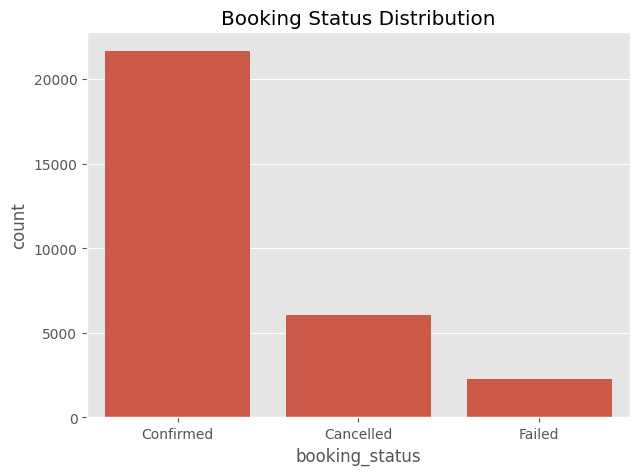

In [11]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='booking_status'
)

plt.title("Booking Status Distribution")

plt.show()

Confirmed bookings dominate the dataset, while approximately 20% of bookings are cancelled, indicating significant revenue leakage.

**SECTION 2**

**Booking Channel Analysis**

In [15]:
channel_summary = (
    df.groupby('booking_channel')
    .agg(
        total_bookings=('customer_id', 'count'),
        total_revenue=('booking_value', 'sum'),
        avg_booking_value=('booking_value', 'mean')
    )
    .reset_index()
)

channel_summary

,booking_channel,total_bookings,total_revenue,avg_booking_value
0,Mobile App,12009,2.564076e+08,21351.285716
1,Travel Agent,2990,7.311738e+07,24453.972990
2,Web,15001,4.228908e+08,28190.840225


In [16]:
channel_summary = (
    df.groupby('booking_channel')
    .agg(
        total_bookings=('customer_id', 'count'),
        total_revenue=('booking_value', 'sum'),
        avg_booking_value=('booking_value', 'mean')
    )
    .reset_index()
)

channel_summary

,booking_channel,total_bookings,total_revenue,avg_booking_value
0,Mobile App,12009,2.564076e+08,21351.285716
1,Travel Agent,2990,7.311738e+07,24453.972990
2,Web,15001,4.228908e+08,28190.840225


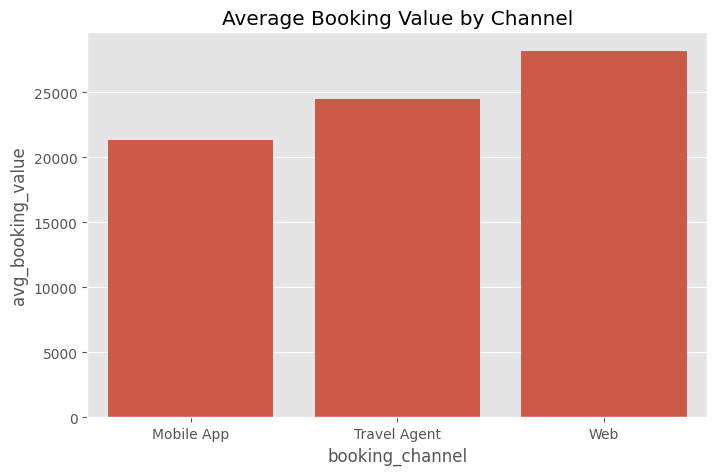

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=channel_summary,
    x='booking_channel',
    y='avg_booking_value'
)

plt.title("Average Booking Value by Channel")

plt.show()

Web bookings generate the highest average booking value, suggesting that direct customers contribute more revenue per transaction.

**SECTION 3**

 **Cancellation Analysis**

In [18]:
cancel_data = df[
    df['booking_status']=='Cancelled'
]

In [19]:
cancel_channel = (
    df.groupby('booking_channel')
    ['booking_status']
    .apply(
        lambda x:
        (x=='Cancelled').mean()*100
    )
    .reset_index()
)

cancel_channel.columns = [
    'booking_channel',
    'cancellation_rate'
]

cancel_channel

,booking_channel,cancellation_rate
0,Mobile App,21.558831
1,Travel Agent,27.926421
2,Web,17.638824


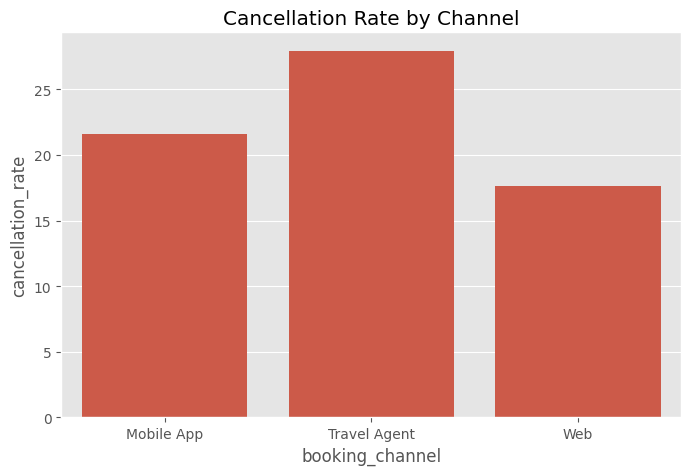

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=cancel_channel,
    x='booking_channel',
    y='cancellation_rate'
)

plt.title("Cancellation Rate by Channel")

plt.show()

Travel Agent bookings show the highest cancellation rate, indicating lower booking commitment and potential inefficiencies in third-party channels.

**SECTION 4**

 **Room Type Analysis**

In [23]:
room_summary = (
    df.groupby('room_type')
    .agg(
        total_bookings=('customer_id','count'),
        revenue=('booking_value','sum')
    )
)

In [24]:
room_summary = (
    df.groupby('room_type')
    .agg(
        total_bookings=('customer_id','count'),
        revenue=('booking_value','sum')
    )
)

In [25]:
room_cancel = (
    df.groupby('room_type')
    ['booking_status']
    .apply(
        lambda x:
        (x=='Cancelled').mean()*100
    )
)

room_cancel

,booking_status
room_type,
Deluxe,16.024050
Standard,23.302320
Suite,17.979798


Standard rooms experience the highest cancellation rates, suggesting stronger price sensitivity among customers selecting budget accommodation.

**SECTION 5**

**Star Rating Analysis**

In [26]:
star_summary = (
    df.groupby('star_rating')
    .agg(
        bookings=('customer_id','count'),
        revenue=('booking_value','sum')
    )
)

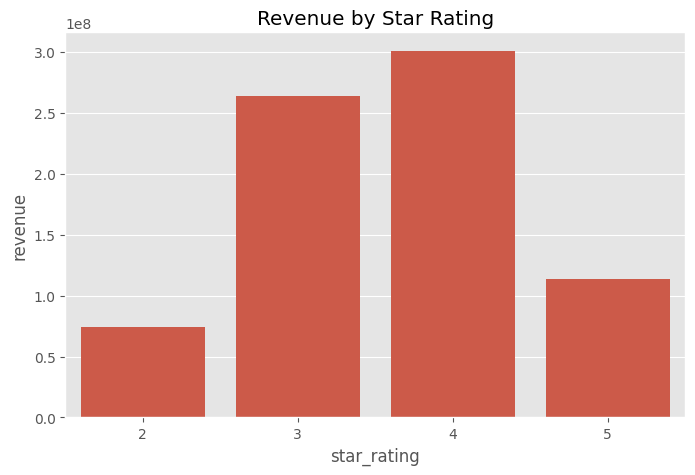

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=star_summary.index,
    y=star_summary['revenue']
)

plt.title("Revenue by Star Rating")

plt.show()

Higher star-rated properties generate significantly higher revenue, demonstrating customers' willingness to pay for premium experiences.

**SECTION 6**

**Refund Analysis**

In [28]:
refund_summary = (
    df.groupby('booking_status')
    ['refund_amount']
    .sum()
)

refund_summary

,refund_amount
booking_status,
Cancelled,1.963069e+06
Confirmed,6.956479e+06
Failed,7.086034e+05


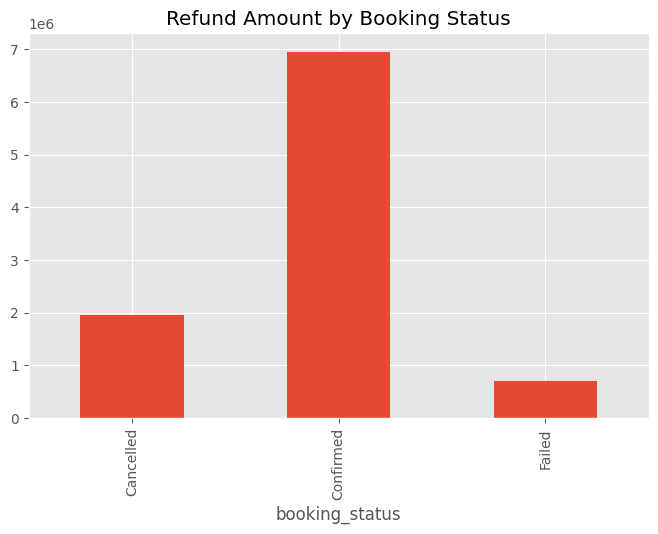

In [29]:
refund_summary.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Refund Amount by Booking Status")

plt.show()

**SECTION 7**

**Monthly Trend Analysis**

In [33]:
monthly_bookings = (
    df.groupby('booking_month')
    ['customer_id']
    .count()
)

monthly_bookings

,customer_id
booking_month,
April,4494
August,2360
December,2360
February,2132
January,2360
July,2361
June,2284
March,2360
May,2360


In [34]:
monthly_revenue = (
    df.groupby('booking_month')
    ['booking_value']
    .sum()
)

monthly_revenue

,booking_value
booking_month,
April,1.128735e+08
August,6.151278e+07
December,5.493369e+07
February,5.928334e+07
January,5.528121e+07
July,6.020926e+07
June,5.527916e+07
March,6.446651e+07
May,5.474528e+07


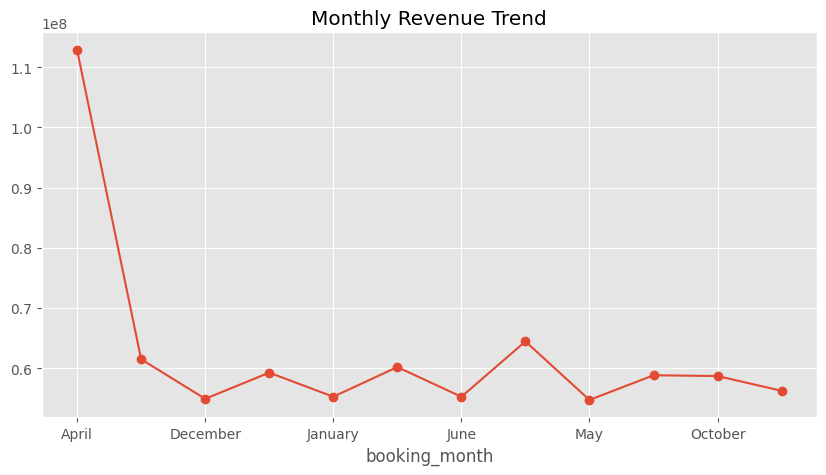

In [35]:
monthly_revenue.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title("Monthly Revenue Trend")

plt.show()

**SECTION 8**

**Stay Length Analysis**

In [38]:
df[['check_in_date','check_out_date']].head()

,check_in_date,check_out_date
0,2024-05-24,2024-05-26
1,2024-05-10,2024-05-17
2,2024-05-31,2024-06-05
3,2024-04-18,2024-04-24
4,NaT,NaT


In [39]:
df[['check_in_date','check_out_date']].dtypes

,0
check_in_date,datetime64[ns]
check_out_date,datetime64[ns]


In [40]:
df['check_in_date'] = pd.to_datetime(df['check_in_date'])
df['check_out_date'] = pd.to_datetime(df['check_out_date'])

In [41]:
df['stay_length'] = (
    df['check_out_date'] -
    df['check_in_date']
).dt.days

In [42]:
df[['check_in_date','check_out_date','stay_length']].head()

,check_in_date,check_out_date,stay_length
0,2024-05-24,2024-05-26,2.0
1,2024-05-10,2024-05-17,7.0
2,2024-05-31,2024-06-05,5.0
3,2024-04-18,2024-04-24,6.0
4,NaT,NaT,NaN


In [43]:
df['stay_length'].describe()

,stay_length
count,24532.000000
mean,4.006848
std,2.001231
min,1.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,7.000000


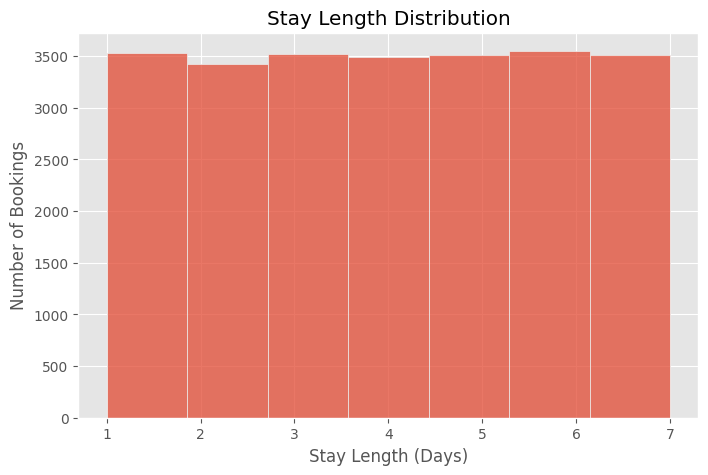

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['stay_length'],
    bins=7
)

plt.title("Stay Length Distribution")
plt.xlabel("Stay Length (Days)")
plt.ylabel("Number of Bookings")

plt.show()